%pip install -U -q numpy pandas wfdb matplotlib notebook PyWavelets scikit-learn

In [1]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
import sklearn


from sklearn.linear_model import LinearRegression
from processor import SignalProcessor
from funkcje import analiza_falkowa, analiza_koherencji

In [2]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis1'     # Nazwa rekordu (.hea i .dat)

In [3]:
os.makedirs(data_dir, exist_ok=True)

local_path = os.path.join(data_dir, record_name)
# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # ['ABP', 'ECG', 'ICP']

# channel_ICP = signals[:,2]
# channel_ABP = signals[:,0]

milestone = SignalProcessor(signals[:,2], signals[:,0], fs)

Rekord: charis1
Długość: 12239851 próbek (68.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


In [7]:
milestone.filtracja_sygnalow(lowcut = 0.02, highcut = 10.0)
milestone.usun_szumy()
srednie_icp, srednie_abp = milestone.packet_averaging(5)

n_samples = len(srednie_icp)
t_max = n_samples / milestone.fs  # całkowity czas trwania okna w sekundach
t = np.linspace(0, t_max, n_samples)

Sygnały przefiltrowane.
Szumy usunięte.


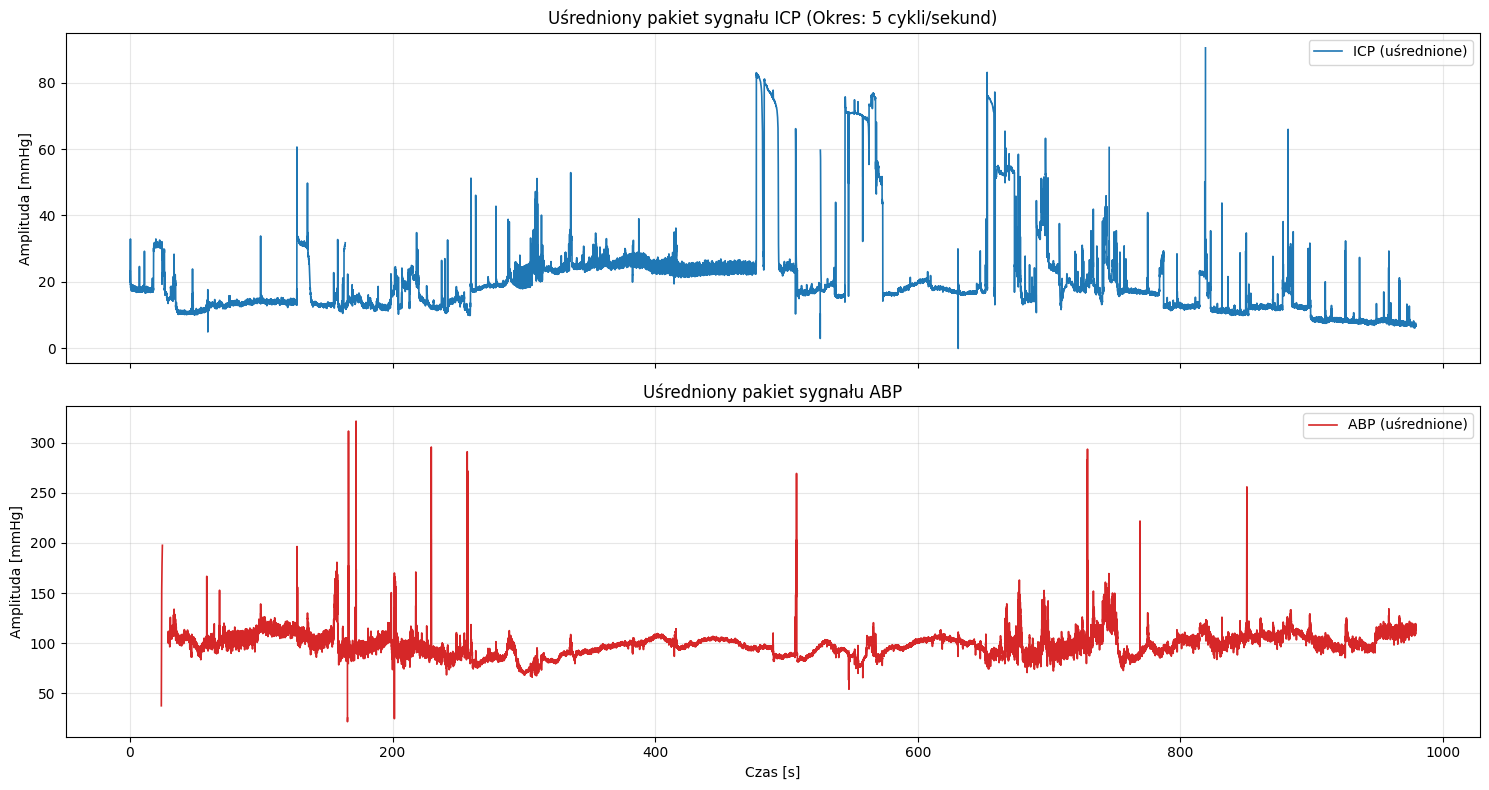

In [8]:
# Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Wykres ICP
ax1.plot(t, srednie_icp, color='#1f77b4', linewidth=1.2, label='ICP (uśrednione)')
ax1.set_ylabel('Amplituda [mmHg]') # lub jednostka Twojego sygnału
ax1.set_title('Uśredniony pakiet sygnału ICP (Okres: 5 cykli/sekund)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Wykres ABP
ax2.plot(t, srednie_abp, color='#d62728', linewidth=1.2, label='ABP (uśrednione)')
ax2.set_xlabel('Czas [s]')
ax2.set_ylabel('Amplituda [mmHg]')
ax2.set_title('Uśredniony pakiet sygnału ABP')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()